# Command-based routing

This notebook builds two small graphs. The first is a non-LLM example that
shows a node routing to one of two other nodes with `Command`. The second is a
support-ticket triage graph: an LLM node classifies an incoming ticket with
structured output and then routes to a `billing`, `technical`, or `general`
handler node, updating state and choosing the next node in the same return
value. Both graphs skip `add_conditional_edges` entirely.

Imports: the graph pieces we already use, plus `Command` from `langgraph.types`, `Literal` for the return-type hint, and `BaseModel`/`Field` for the structured classification output.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langgraph.types import Command
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)

## Part 1: a tiny non-LLM example

Before bringing an LLM in, here is the smallest possible `Command` example. A node looks at a number in state and routes to `double` or `halve` without any conditional edge. `Command(update=..., goto=...)` does two things in one return value: it updates the state and it names the next node.

In [4]:
class NumberState(TypedDict):
    value: int
    path: str


def router(state: NumberState) -> Command[Literal["double", "halve"]]:
    if state["value"] % 2 == 0:
        return Command(update={"path": "double"}, goto="double")
    return Command(update={"path": "halve"}, goto="halve")


def double(state: NumberState) -> dict:
    return {"value": state["value"] * 2}


def halve(state: NumberState) -> dict:
    return {"value": state["value"] // 2}

Build the graph. Notice there is no `graph.add_conditional_edges(...)` call, and `double`/`halve` need no edge to `END` either — a node with no outgoing edge simply ends the run, same as with regular edges.

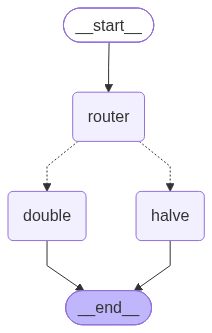

In [5]:
number_graph = StateGraph(NumberState)
number_graph.add_node("router", router)
number_graph.add_node("double", double)
number_graph.add_node("halve", halve)
number_graph.add_edge(START, "router")

number_app = number_graph.compile()
number_app

In [6]:
print(number_app.invoke({"value": 4, "path": ""}))
print(number_app.invoke({"value": 7, "path": ""}))

{'value': 8, 'path': 'double'}
{'value': 3, 'path': 'halve'}


## Part 2: LLM support-ticket triage

Now the real example. A ticket comes in as plain text. A classification node asks the LLM which category it belongs to, using structured output so the result is always one of the three literal categories rather than free text. The same node then returns a `Command` that both stores the category in state and sends the graph straight to the matching handler node.

In [7]:
class TicketCategory(BaseModel):
    category: Literal["billing", "technical", "general"] = Field(
        description="The best-matching category for the support ticket"
    )


classifier = llm.with_structured_output(TicketCategory)

In [8]:
class TicketState(TypedDict):
    ticket: str
    category: str
    response: str

The triage node is annotated `-> Command[Literal["billing", "technical", "general"]]`. That hint is not just documentation: LangGraph reads it to know which nodes this node might send the graph to, so it can validate and draw the graph without an explicit conditional edge.

In [9]:
def triage_node(state: TicketState) -> Command[Literal["billing", "technical", "general"]]:
    result = classifier.invoke(
        f"Classify this support ticket as billing, technical, or general:\n{state['ticket']}"
    )
    return Command(update={"category": result.category}, goto=result.category)

In [10]:
def billing_node(state: TicketState) -> dict:
    return {"response": f"[Billing team] We received your ticket: '{state['ticket']}'"}


def technical_node(state: TicketState) -> dict:
    return {"response": f"[Technical team] We received your ticket: '{state['ticket']}'"}


def general_node(state: TicketState) -> dict:
    return {"response": f"[General support] We received your ticket: '{state['ticket']}'"}

Building the graph looks the same as any other `StateGraph`, except the only edge needed is `START -> triage_node`. The `Command` returned by `triage_node` supplies the rest of the routing at run time.

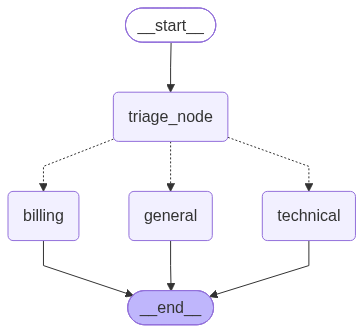

In [11]:
ticket_graph = StateGraph(TicketState)
ticket_graph.add_node("triage_node", triage_node)
ticket_graph.add_node("billing", billing_node)
ticket_graph.add_node("technical", technical_node)
ticket_graph.add_node("general", general_node)
ticket_graph.add_edge(START, "triage_node")

ticket_app = ticket_graph.compile()
ticket_app

Run it on three tickets that clearly belong to different categories, and check that each one lands on the matching handler.

In [12]:
tickets = [
    "I was charged twice for my subscription this month.",
    "The app crashes every time I try to upload a file.",
    "What are your support hours?",
]

for ticket in tickets:
    result = ticket_app.invoke({"ticket": ticket, "category": "", "response": ""})
    print(result["category"], "->", result["response"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


billing -> [Billing team] We received your ticket: 'I was charged twice for my subscription this month.'


technical -> [Technical team] We received your ticket: 'The app crashes every time I try to upload a file.'


general -> [General support] We received your ticket: 'What are your support hours?'
